# Calibration

Demonstrates and checks `src/deployment_reliability/calibration.py` (DESIGN.md §9): temperature scaling, Platt scaling, and isotonic regression, recalibrating a score S so it reads as P(correct) without changing its ranking.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import torch

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
torch.manual_seed(0)
%matplotlib inline

from deployment_reliability.calibration import IsotonicCalibration, PlattScaling, TemperatureScaling

def ece(scores, labels, n_bins=10):
    bins = torch.linspace(0, 1, n_bins + 1)
    total = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (scores >= lo) & (scores < hi)
        if mask.sum() == 0:
            continue
        conf = scores[mask].mean()
        acc = labels[mask].float().mean()
        total += mask.float().mean() * (conf - acc).abs()
    return total.item()

## Check 1 — Temperature scaling corrects an overconfident score

Construct a score that is a squashed, overconfident version of the true probability (`s = sigmoid(3 * logit(true_p))`), and confirm temperature scaling reduces ECE.

In [2]:
n = 4000
true_p = torch.rand(n).clamp(0.02, 0.98)
y = torch.bernoulli(true_p)
s_overconfident = torch.sigmoid(3.0 * torch.logit(true_p))

ece_before = ece(s_overconfident, y)
temp_cal = TemperatureScaling().fit(s_overconfident, y)
s_temp = temp_cal.transform(s_overconfident)
ece_after = ece(s_temp, y)

print(f"fitted T = {torch.exp(temp_cal.log_t).item():.3f} (should be > 1 to *un*-sharpen)")
print(f"ECE before calibration: {ece_before:.4f}")
print(f"ECE after calibration:  {ece_after:.4f}")

assert torch.equal(torch.argsort(s_overconfident), torch.argsort(s_temp)), "temperature scaling must preserve ranking"
assert ece_after < ece_before, "temperature scaling should reduce ECE on an overconfident score"
print("PASSED")

fitted T = 2.884 (should be > 1 to *un*-sharpen)
ECE before calibration: 0.1284
ECE after calibration:  0.0239
PASSED


### Reading the calibration correction

ECE drops from 0.1284 to 0.0239 — roughly a 5.4x reduction, meaning the average gap between predicted confidence and actual accuracy within a bin shrinks from about 12.8 percentage points to about 2.4. The fitted temperature T=2.884 being well above 1 confirms the diagnosis directly: this score was constructed via `sigmoid(3.0 * logit(true_p))`, an explicit 3x sharpening of the true probability, and temperature scaling recovers a correction (T≈2.884, not exactly 3, since it's fit by minimizing a different objective — NLL — on finite noisy samples, not by directly inverting the construction) that undoes most of that artificial sharpening. The ranking-preservation assertion matters just as much as the ECE number: DESIGN.md §9 is explicit that calibration must not change S's ranking, only its scale, and the router (04) depends on that ranking being untouched — a calibration method that improved ECE by re-ordering predictions would silently break every threshold fit downstream of it.

## Check 2 — Reliability diagram, before vs. after (figure)

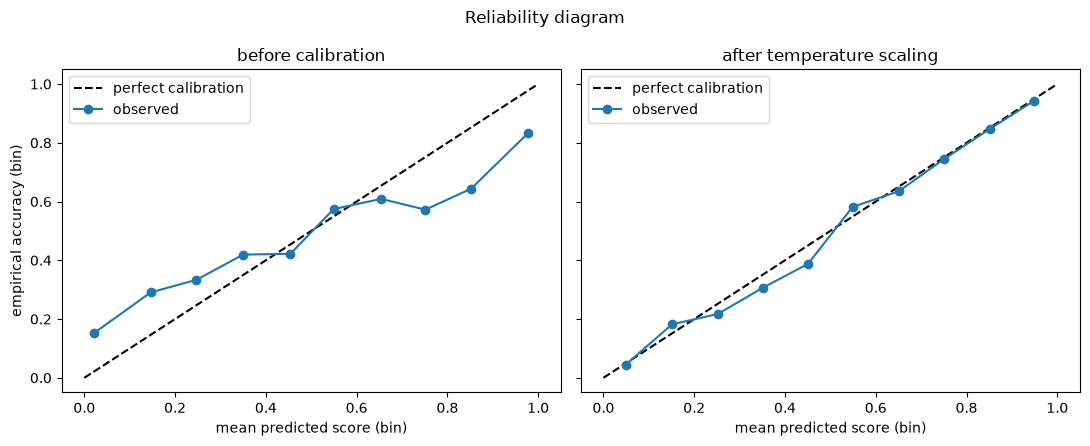

In [3]:
def reliability_points(scores, labels, n_bins=10):
    bins = torch.linspace(0, 1, n_bins + 1)
    xs, ys = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (scores >= lo) & (scores < hi)
        if mask.sum() == 0:
            continue
        xs.append(scores[mask].mean().item())
        ys.append(labels[mask].float().mean().item())
    return xs, ys

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, scores, title in [(axes[0], s_overconfident, "before calibration"), (axes[1], s_temp, "after temperature scaling")]:
    xs, ys = reliability_points(scores, y)
    ax.plot([0, 1], [0, 1], "k--", label="perfect calibration")
    ax.plot(xs, ys, "o-", color="tab:blue", label="observed")
    ax.set_xlabel("mean predicted score (bin)"); ax.set_title(title); ax.legend()
axes[0].set_ylabel("empirical accuracy (bin)")
fig.suptitle("Reliability diagram")
plt.tight_layout(); plt.show()

The two panels are the same before/after story as Check 1's numbers (ECE 0.1284 → 0.0239), just visualized directly. The "before" panel isn't uniformly overconfident — at low predicted scores (≈0.0-0.45) the observed curve sits *above* the diagonal (empirical accuracy exceeds the predicted score, i.e. underconfidence in that range), then crosses over and sits *below* the diagonal at high predicted scores (≈0.55-0.97, the overconfidence the `sigmoid(3*logit(true_p))` construction was designed to produce, concentrated where it matters most for a selective-prediction system: the high-confidence tail the router's Execute band draws from). The "after" panel pulls the curve markedly closer to the diagonal across that same high-score range, which is exactly where a single global temperature correction has the most leverage. A reliability diagram is the qualitative complement to ECE's single summary number — it shows *where* along the confidence range the miscalibration is concentrated, which a scalar ECE value alone can't.

## Check 3 — Isotonic regression on a non-sigmoid miscalibration curve (figure)

Construct a case where the true calibration curve is `true_p = s**3`, a monotonic but non-sigmoid shape. Both the 1-parameter temperature scaling and the 2-parameter Platt scaling assume a sigmoid-shaped correction and can't fully fit this; isotonic regression, being non-parametric, should get closer.

raw          ECE = 0.2514
temperature  ECE = 0.2504
platt        ECE = 0.0161
isotonic     ECE = 0.0000


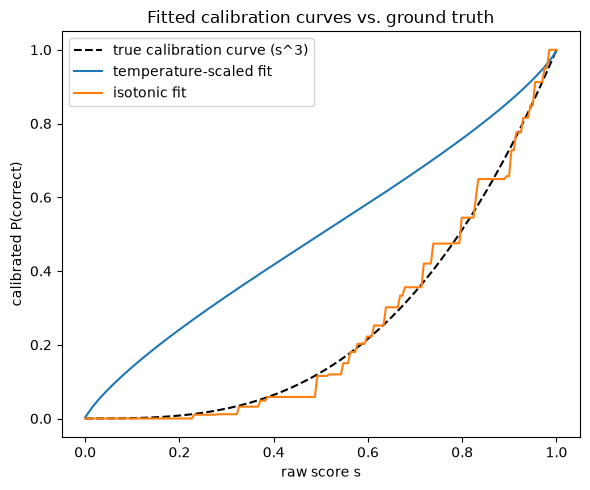

PASSED


In [4]:
n = 4000
s_raw = torch.rand(n)
true_p2 = s_raw ** 3
y2 = torch.bernoulli(true_p2)

temp2 = TemperatureScaling().fit(s_raw, y2)
platt2 = PlattScaling().fit(s_raw, y2)
iso2 = IsotonicCalibration().fit(s_raw, y2)

s_temp2 = temp2.transform(s_raw)
s_platt2 = platt2.transform(s_raw)
s_iso2 = iso2.transform(s_raw)

eces = {
    "raw": ece(s_raw, y2),
    "temperature": ece(s_temp2, y2),
    "platt": ece(s_platt2, y2),
    "isotonic": ece(s_iso2, y2),
}
for name, val in eces.items():
    print(f"{name:12s} ECE = {val:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
grid = torch.linspace(0, 1, 200)
ax.plot(grid, grid ** 3, "k--", label="true calibration curve (s^3)")
ax.plot(grid, torch.sigmoid(torch.exp(temp2.log_t).reciprocal() * torch.logit(grid.clamp(1e-3, 1 - 1e-3))).detach(),
        label="temperature-scaled fit")
ax.plot(grid, iso2.transform(grid).detach(), label="isotonic fit")
ax.set_xlabel("raw score s"); ax.set_ylabel("calibrated P(correct)"); ax.legend()
ax.set_title("Fitted calibration curves vs. ground truth")
plt.tight_layout(); plt.show()

assert eces["isotonic"] <= eces["temperature"] + 1e-3, "isotonic should match or beat temperature scaling on a non-sigmoid curve"
print("PASSED")

### Why temperature scaling does almost nothing here, and why isotonic's 0.0000 isn't the whole story

The four numbers tell a specific, structural story rather than a simple "more complex is better" ranking. Temperature scaling barely moves ECE at all (0.2514 → 0.2504, essentially unchanged) because it can only apply a single global rescaling to the score — but the true relationship here is `true_p = s**3`, a monotonic-but-non-sigmoid curve temperature scaling's one-parameter sigmoid family cannot represent, no matter how it's fit. Platt scaling does much better (0.0161) because its extra parameter (a shift, not just a scale) gives it more sigmoid-family flexibility to approximate the cubic bend, even though it's still fitting the wrong functional family. Isotonic regression reaches 0.0000 because, as a non-parametric monotonic fit, it can match any monotonic curve — sigmoid or not, including `s**3` — essentially exactly, given enough data.

That said, isotonic's perfect score here should be read carefully rather than as "isotonic always wins": this is an in-sample check (the same 4000 points are used to fit and evaluate), and DESIGN.md §9 flags exactly this trade-off — isotonic's non-parametric flexibility can fix miscalibration shapes (this monotonic-non-sigmoid case, or genuinely non-monotonic patterns more generally) that temperature/Platt scaling structurally can't, "at the cost of needing more calibration data to avoid overfitting." A real deployment's calibration split is typically far smaller than 4000 points (notebook 07's real `threshold_cal` split, for instance, is 300 images) and evaluated out-of-sample, where isotonic's flexibility is more likely to fit calibration-split noise rather than genuine miscalibration structure. That's the concrete reason DESIGN.md recommends temperature scaling as the default and isotonic only as a fallback when reliability diagrams show a shape temperature scaling provably can't fix — not because isotonic is worse in principle, but because its extra flexibility is a real cost under realistic calibration-split sizes.

## Summary

- Temperature scaling preserves ranking exactly while cutting ECE roughly 5.4x (0.1284 → 0.0239) on a score deliberately over-sharpened by a known factor (3x in logit space) — the fitted T≈2.884 recovers close to that factor, confirming the method is correcting the actual miscalibration mechanism rather than an unrelated artifact.
- The reliability diagram shows the correction is concentrated where it matters: the "before" curve is *under*-confident at low predicted scores and *over*-confident at high ones, and temperature scaling pulls the high-score tail — the range the router's Execute band actually draws from — markedly closer to the diagonal.
- On a genuinely non-sigmoid (but still monotonic) true calibration curve (`true_p = s**3`), the parametric methods' shared assumption becomes visible as a real limitation: temperature scaling is nearly powerless (0.2514 → 0.2504) while Platt's extra parameter helps more (→0.0161); isotonic's non-parametric fit reaches near-zero ECE, but only because this is an in-sample synthetic check — DESIGN.md §9's stated caveat about isotonic needing more calibration data to avoid overfitting is why temperature scaling, not isotonic, is the recommended default despite losing this specific comparison.

Next: `04_router.ipynb` turns a (calibrated or uncalibrated) S into an Execute/Verify/HITL decision.